# EDA – Gaming & Academic Performance

**Goal:** understand which student habits are associated with `grades`, and check data quality before any modelling.

*Reviewed version: English markdown = conclusions (practise report writing); "Góp ý" boxes = review comments in Vietnamese.*

### Installation
- Pandas
- Matplotlib
- Seaborn


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#readdata
data = pd.read_csv('Gaming_Academic_Performance.csv')

data.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


**Conclusion:** The dataset has **8,000 rows and 14 columns** – 11 numeric and 3 categorical (`gender`, `gaming_genre`, `stress_level`). All data types are correct. `student_id` is only an identifier, so it is excluded from the analysis. `grades` is the target variable.

In [3]:
stress_map = {'Low': 1, 'Medium': 2, 'High': 3} 
data['stress_level_num'] = data['stress_level'].map(stress_map)
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns
target_variable = 'grades'
numerical_features = numerical_features.drop('grades')
numerical_features = numerical_features.drop('student_id')
#categorical_features = categorical_features.drop('stress_level')
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Target Variable:", target_variable)

Numerical Features: Index(['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'social_activity', 'device_usage', 'reaction_time_ms',
       'addiction_score', 'stress_level_num'],
      dtype='object')
Categorical Features: Index(['gender', 'gaming_genre', 'stress_level'], dtype='object')
Target Variable: grades


> **Góp ý (review):**
> Tốt: tách rõ numerical / categorical / target và bỏ `student_id`. Map `stress_level` sang số 1-2-3 là hợp lý vì đây là biến **ordinal** (có thứ tự).
> Lưu ý: `stress_level` giờ nằm ở cả 2 danh sách (dạng số và dạng chữ) – không sai, nhưng khi viết report nên nói rõ.

# 1.Clean Data

## 1.1. Data Understanding

In [4]:
data.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades,stress_level_num
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776,1.783375
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024,0.649809
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000,1.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843,1.000000
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000,2.000000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223,2.000000
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936,3.000000


**Conclusion:**
- For most variables, the mean is very close to the median, which suggests **symmetric distributions**.
- Many variables have "hard" limits (e.g. `gaming_hours` 0–8, `study_hours` 1–10, `sleep_hours` 4–9, `attendance` 60–100). This pattern suggests the data is **synthetic** (generated), not collected from real students.
- Two values are **impossible** in the real world and need checking (see 1.4):
  - `addiction_score` has a minimum of **-4.51** – a score should not be negative.
  - `grades` has a maximum of **118.6** – grades should not be above 100.

In [5]:
data[categorical_features].nunique()

gender          3
gaming_genre    3
stress_level    3
dtype: int64

**Conclusion:** Each categorical variable has only 3 levels, so they are easy to encode (one-hot for `gender`, `gaming_genre`; ordinal for `stress_level`).

## 1.2. Check missing value

In [6]:
data.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
stress_level_num    0
dtype: int64

Conclusion: There is no null cell in this table

## 1.3. Check duplicate

In [7]:
data.duplicated().sum()

np.int64(0)

> **Góp ý (review):**
> **Có bug logic:** `data.duplicated()` so sánh cả cột `student_id`. Vì mỗi dòng có id khác nhau nên kết quả **luôn luôn = 0**, dù có 2 học sinh bị nhập trùng. Cần kiểm tra trùng **sau khi bỏ id**, và kiểm tra id có bị trùng không.

In [8]:
print('Duplicate rows (ignoring student_id):', data.drop(columns='student_id').duplicated().sum())
print('Duplicate student_id:', data['student_id'].duplicated().sum())

Duplicate rows (ignoring student_id): 0
Duplicate student_id: 0


**Conclusion:** There are no duplicated records, even when `student_id` is ignored, and every `student_id` is unique.

## 1.4. Inconsistent values

> **Góp ý (review):**
> Tiêu đề cũ là "Inconsistent categorical variables" nhưng cell lại chạy `data.describe()` lần 2 (trùng với 1.1). Mình tách ra: (a) kiểm tra **giá trị vô lý theo domain** cho biến số, (b) kiểm tra chính tả cho biến categorical.
> Kết luận cũ "every numerical column is consistent" **chưa đúng** – xem kết quả bên dưới.

In [9]:
# (a) Domain checks: values that are impossible in the real world
checks = {
    'grades > 100': (data['grades'] > 100).sum(),
    'grades == 100 (exactly)': (data['grades'] == 100).sum(),
    'addiction_score < 0': (data['addiction_score'] < 0).sum(),
}
checks

{'grades > 100': np.int64(134),
 'grades == 100 (exactly)': np.int64(439),
 'addiction_score < 0': np.int64(107)}

In [10]:
# Number of decimals in grades: all other columns have 2 decimals
n_decimals = data['grades'].astype(str).str.split('.').str[1].str.len()
data['grades_messy'] = n_decimals > 2
print('Grades with more than 2 decimals:', data['grades_messy'].sum())
data.groupby('grades_messy')['grades'].describe().round(2)

Grades with more than 2 decimals: 1671


,count,mean,std,min,25%,50%,75%,max
grades_messy,,,,,,,,
False,6329.0,63.81,22.86,0.00,47.01,63.52,82.46,100.00
True,1671.0,75.16,18.03,6.52,63.76,76.50,87.14,118.63


**Conclusion:**
- **134 grades are above 100** (max 118.6) and **107 addiction scores are negative**. These are *invalid values* (errors), not just unusual values.
- **439 grades are exactly 100**. This suggests grades were **capped at 100** (ceiling effect).
- **1,671 grades have many decimals** (e.g. 86.459555) while every other value has 2 decimals. All 134 grades above 100 belong to this group, and its mean is higher (75.2 vs 63.8). This group was probably **modified after generation** (e.g. noise added after capping).
- **Recommended handling** (before modelling): clip `grades` to [0, 100] and `addiction_score` to ≥ 0, or keep a flag column. Because these rows are only 1–2% of the data, the EDA results below are not strongly affected, so the original values are kept here.

In [11]:
{col: data[col].unique() for col in categorical_features}

{'gender': array(['Male', 'Female', 'Other'], dtype=object),
 'gaming_genre': array(['FPS', 'Casual', 'RPG'], dtype=object),
 'stress_level': array(['Low', 'Medium', 'High'], dtype=object)}

Conclusion: Every categorical columns is consistant and no error

## 1.5. Outliers

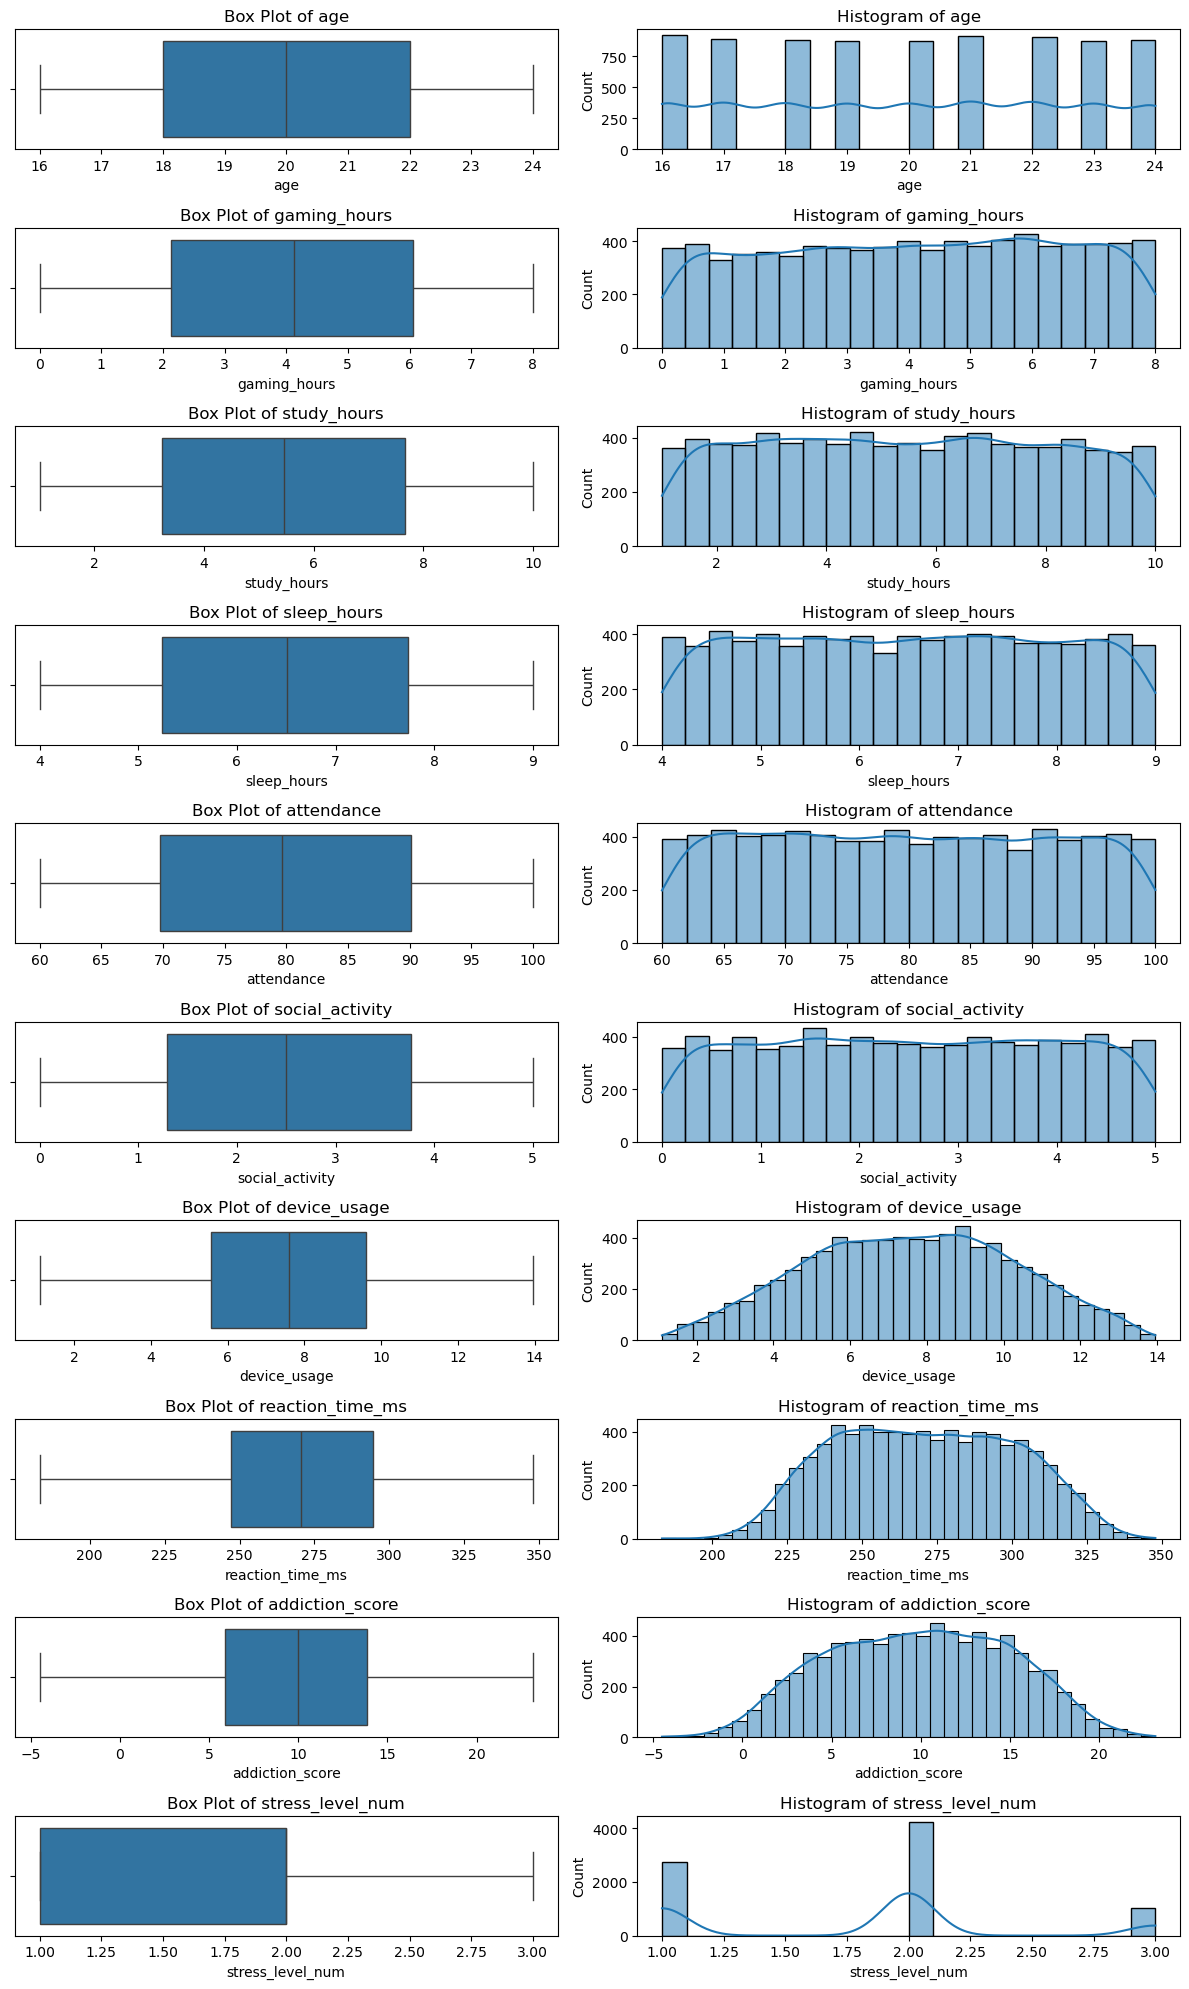

In [12]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 2*len(numerical_features)))
for i, col in enumerate(numerical_features):
    sns.boxplot(x=data[col], ax=axes[i, 0])
    sns.histplot(data[col], kde=True, ax=axes[i, 1])
    axes[i, 0].set_title(f'Box Plot of {col}')
    axes[i, 1].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


**Conclusion:** Based on the IQR rule (box plots), **no variable has points outside the whiskers**, so there are no *statistical* outliers to remove.
However, "no statistical outliers" does **not** mean "no errors": the invalid values found in 1.4 (grades > 100, negative addiction scores) are still inside the whiskers of each box plot.

> **Góp ý (review):**
> - Box plot không phù hợp cho `stress_level_num` (chỉ có 3 giá trị) – nên dùng countplot.
> - Histogram của `age` có khoảng trống vì `age` là số nguyên; thêm `discrete=True` trong `sns.histplot` sẽ đẹp hơn.
> - Nếu lấy ngưỡng outlier theo IQR thì nên in ra số lượng bằng code (`((x < Q1-1.5*IQR) | (x > Q3+1.5*IQR)).sum()`), thay vì chỉ nhìn hình.

# 2. Exploratory Data Analysis

## 2.1. Univariate

In [13]:
data[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,19.983625,2.587072,16.00,18.0000,20.000,22.00,24.00
gaming_hours,8000.0,4.085773,2.308801,0.00,2.1300,4.130,6.06,8.00
study_hours,8000.0,5.460581,2.575787,1.00,3.2400,5.460,7.66,10.00
sleep_hours,8000.0,6.493453,1.442656,4.00,5.2400,6.505,7.73,9.00
attendance,8000.0,79.886525,11.580419,60.00,69.7800,79.695,90.10,100.00
social_activity,8000.0,2.507790,1.441128,0.00,1.2875,2.500,3.76,5.00
device_usage,8000.0,7.586315,2.710035,1.10,5.5600,7.610,9.60,13.95
reaction_time_ms,8000.0,271.105839,29.440675,183.26,247.1600,270.475,294.69,347.87
addiction_score,8000.0,9.908492,5.035837,-4.51,5.9200,10.005,13.86,23.16
stress_level_num,8000.0,1.783375,0.649809,1.00,1.0000,2.000,2.00,3.00


In [14]:
data[numerical_features].skew()


age                -0.002101
gaming_hours       -0.057435
study_hours         0.022475
sleep_hours         0.004045
attendance          0.021198
social_activity    -0.003978
device_usage       -0.010724
reaction_time_ms    0.046683
addiction_score    -0.030470
stress_level_num    0.247619
dtype: float64

**Conclusion:** All skewness values are between -0.06 and 0.25 (|skew| < 0.5), so every numerical feature is **approximately symmetric**. No log/Box-Cox transformation is needed.

<Axes: xlabel='grades', ylabel='Count'>

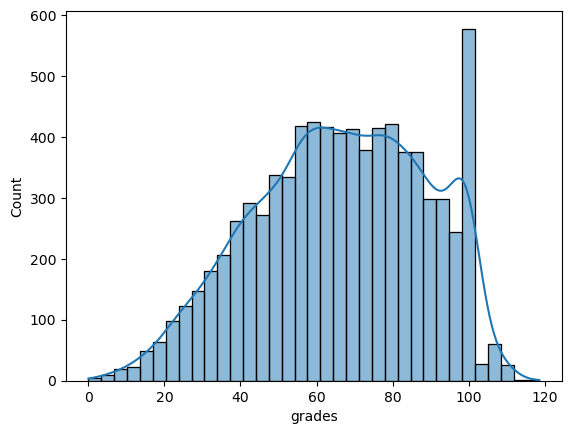

In [15]:
sns.histplot(data[target_variable], kde=True)


**Conclusion (target `grades`):**
- Mean = 66.2, median = 67.1. The distribution is **slightly left-skewed** (skew ≈ -0.25): a long tail towards low grades (down to 0).
- There is a **sharp spike at exactly 100** (439 students) – a ceiling effect caused by capping – plus a small group above 100 (invalid, see 1.4).
- Because of the ceiling and the skew, grades are not normally distributed. This supports using **non-parametric tests** (Spearman, Kruskal-Wallis) later.

**Conclusions (numerical features):**
- `age` is a discrete integer from 16 to 24, with about the same number of students at each age.
- `gaming_hours`, `study_hours`, `sleep_hours`, `attendance` and `social_activity` follow an approximately **uniform distribution** (flat histograms) across their ranges. Real behavioural data rarely looks like this, which again suggests synthetic data.
- `device_usage`, `reaction_time_ms` and `addiction_score` have **bell-shaped / flat-topped (trapezoid)** distributions. This shape appears when a uniform variable is combined with random noise – a first hint that these three are **derived from `gaming_hours`** (confirmed in 2.2).
- `stress_level_num` has only 3 values: Medium is the most common and High the least common.

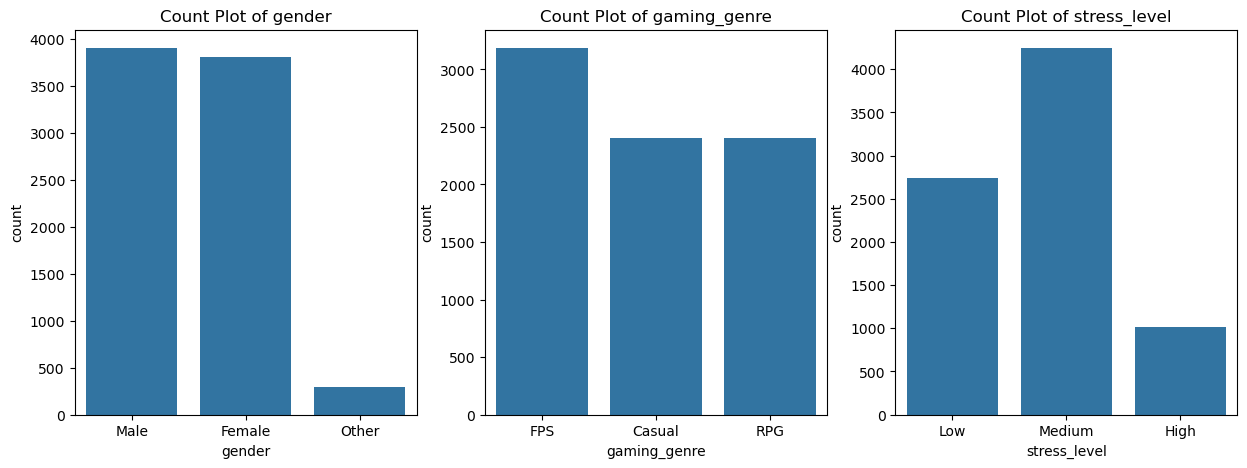

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_features), figsize=(15, 5))
for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=data, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
plt.show()

In [17]:
# Percentages are easier to report than raw counts
for col in categorical_features:
    print(data[col].value_counts(normalize=True).mul(100).round(1), '\n')

gender
Male      48.8
Female    47.5
Other      3.7
Name: proportion, dtype: float64 

gaming_genre
FPS       39.8
RPG       30.1
Casual    30.1
Name: proportion, dtype: float64 

stress_level
Medium    53.1
Low       34.3
High      12.6
Name: proportion, dtype: float64 



**Conclusions (categorical features):**
- **Gender:** Male (48.8%) and Female (47.5%) are balanced; **Other is a small group (3.7%, ~300 students)**, so any result for this group is less reliable.
- **Gaming genre:** FPS is the most popular (39.8%); Casual and RPG are equal (30.1% each).
- **Stress level:** Medium 53.1%, Low 34.3%, High 12.6% – the classes are **imbalanced**. If `stress_level` is used as a target in a future classification task, class imbalance must be handled.

> **Góp ý (review):**
> Nên thêm `order=['Low','Medium','High']` cho biến ordinal để trục x theo đúng thứ tự, và hiển thị % trên cột (`ax.bar_label`).

## 2.2. Bivariate Analysis

> **Góp ý (review):**
> Tiêu đề cũ bị trùng số "2.1" và dùng tên "Multivariate" 2 lần. Phần này là quan hệ **từng feature với target** → gọi là *Bivariate*.

In [18]:
correlation_table = pd.DataFrame({
    "pearson": data[numerical_features].corrwith(data[target_variable], method='pearson'),
    "spearman": data[numerical_features].corrwith(data[target_variable], method='spearman')
}).round(3)
correlation_table

,pearson,spearman
age,0.008,0.010
gaming_hours,-0.551,-0.540
study_hours,0.733,0.741
sleep_hours,0.250,0.243
attendance,0.131,0.126
social_activity,-0.019,-0.017
device_usage,-0.468,-0.464
reaction_time_ms,0.517,0.510
addiction_score,-0.495,-0.491
stress_level_num,0.496,0.497


**Conclusion:**
- **`study_hours` is the strongest predictor** (r = 0.73): more study is linked to higher grades.
- **Negative relationships:** `gaming_hours` (-0.55), `addiction_score` (-0.50) and `device_usage` (-0.47).
- **Weak positive:** `sleep_hours` (0.25) and `attendance` (0.13).
- **No relationship:** `age` and `social_activity` (|r| < 0.02).
- **Two counter-intuitive results** need explanation:
  - `reaction_time_ms` is *positive* (0.52): slower reaction → higher grades?
  - `stress_level_num` is *positive* (0.50): more stress → higher grades?
  These are investigated below (2.3 and 2.4).
- Pearson and Spearman values are almost identical for every feature, so the relationships are **approximately linear** and not driven by extreme values.

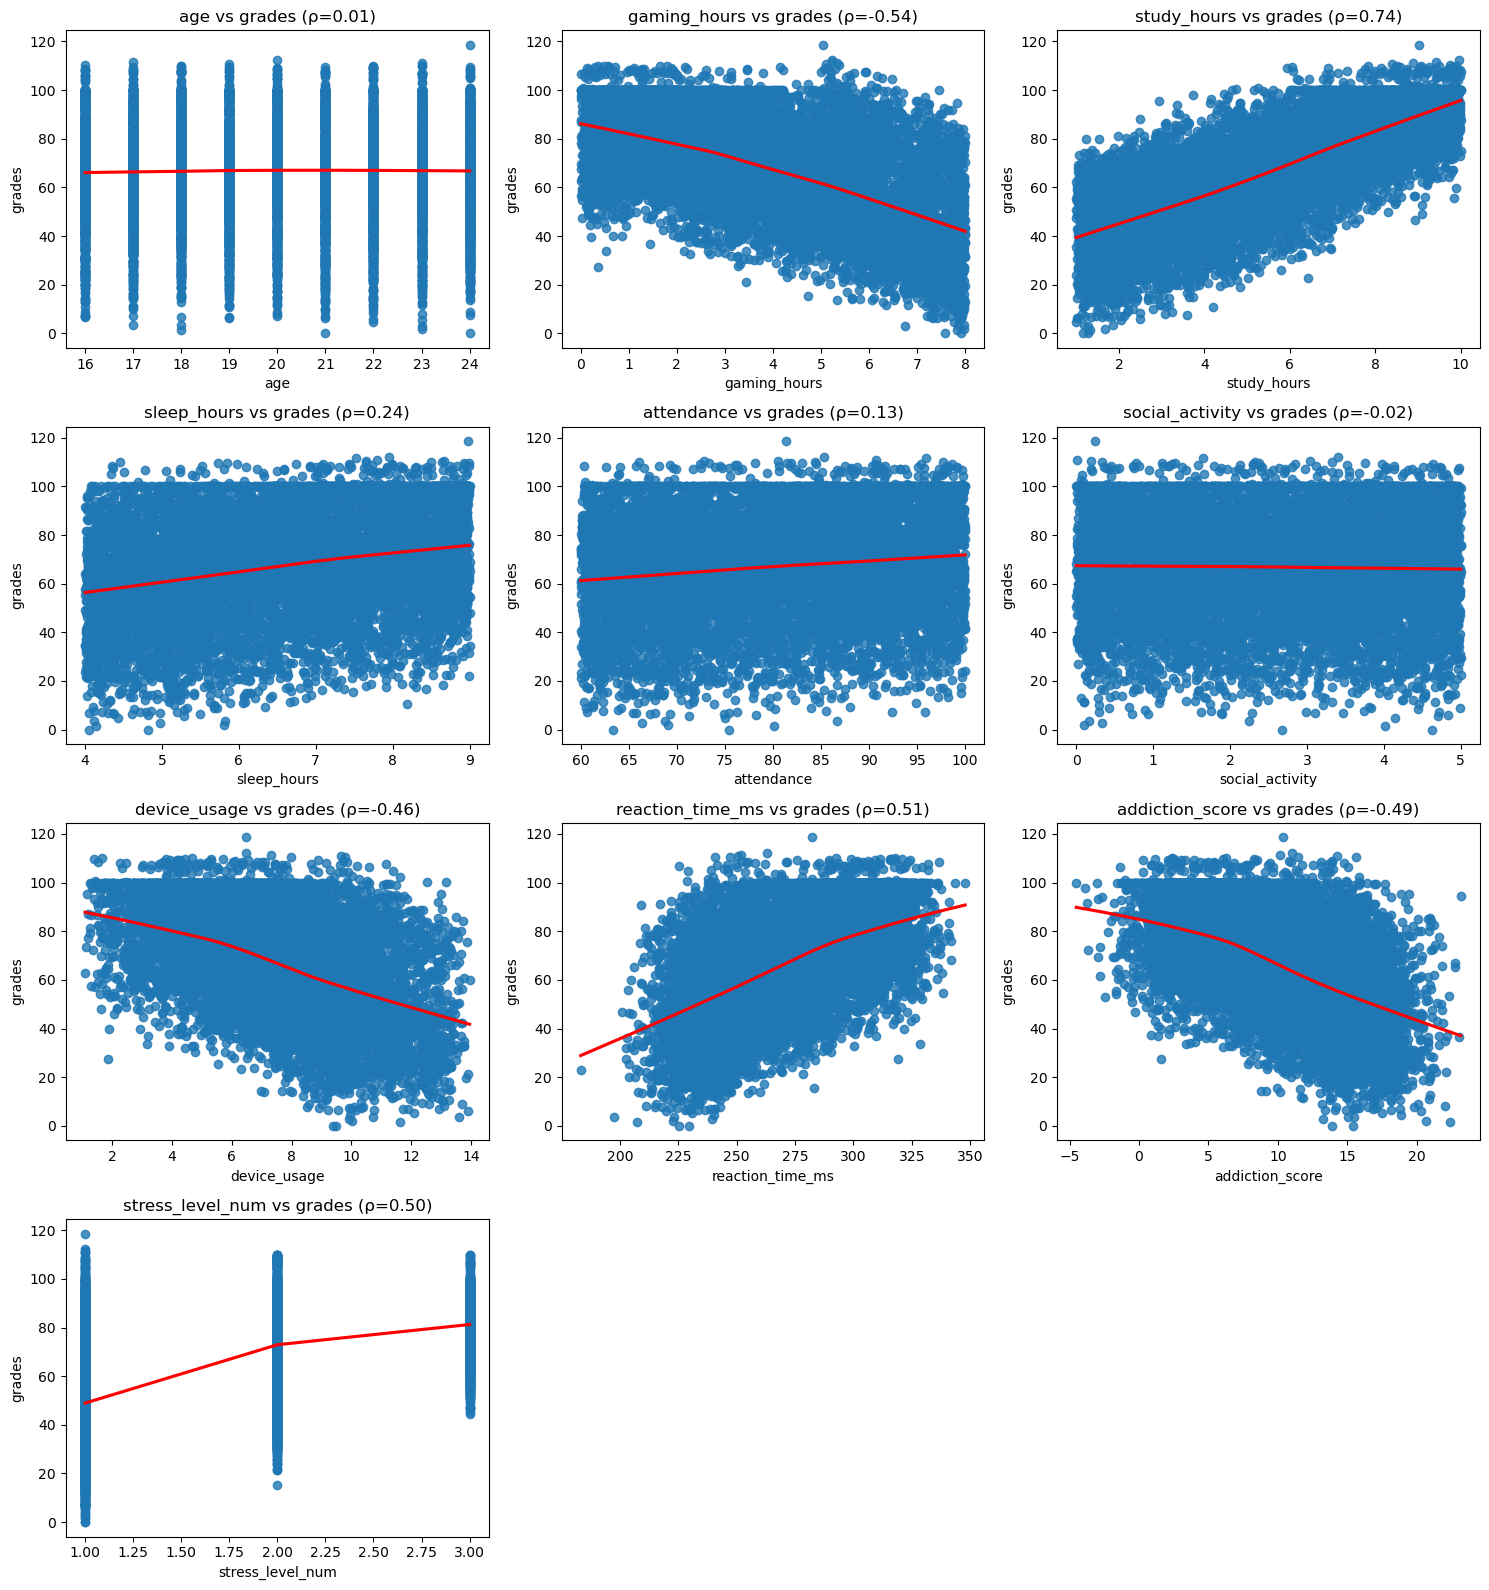

In [19]:
n = len(numerical_features)

fig, axes = plt.subplots((n+2)//3, 3, figsize =(15, 4*((n+2)//3)))
for ax, col in zip(axes.flat, numerical_features):
    sns.regplot(data = data, x = col, y = target_variable, ax = ax, lowess=True, line_kws={"color":"red"})
    ax.set_title(f'{col} vs {target_variable} (ρ={data[col].corr(data[target_variable], method="spearman"):.2f})')
for ax in axes.flat[n:]:
    ax.set_visible(False)   # hide empty subplots
plt.tight_layout()
plt.show()

**Conclusion:** The LOWESS lines (red) confirm the correlation table: clear upward trend for `study_hours`, downward trends for `gaming_hours`, `device_usage` and `addiction_score`, and flat lines for `age` and `social_activity`. Most trends are close to straight lines, so a **linear model is a reasonable first choice**. The horizontal band of points at grades = 100 shows the ceiling effect again.

> **Góp ý (review):**
> 8.000 điểm bị chồng lên nhau (overplotting) nên scatter thành "mảng xanh". Nên thêm `scatter_kws={'alpha':0.1, 's':5}` như bạn đã làm ở cell sau.

> **Góp ý (review):**
> **Có bug vẽ hình:** vòng lặp vẽ 3 boxplot lên **cùng một axes**, nên hình cũ bị trộn 9 hộp với nhãn trục x là "gender". Sửa bằng `plt.subplots(1, 3)`. Mình cũng thêm **effect size** (epsilon²) vì với n = 8000, p-value gần như luôn nhỏ – cần biết khác biệt *lớn* cỡ nào.

gender        H=    2.07  p=0.3544  eps²=0.000
gaming_genre  H=    0.74  p=0.6915  eps²=0.000
stress_level  H= 2027.27  p=0  eps²=0.253


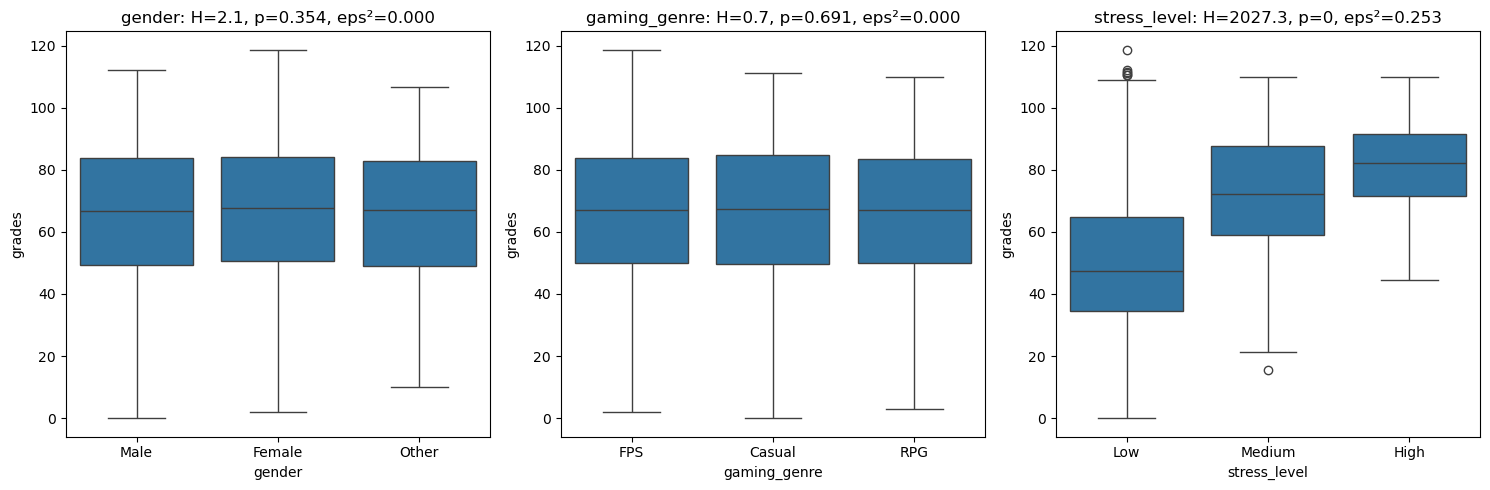

stress_level
High      82.05
Low       47.36
Medium    72.08
Name: grades, dtype: float64

In [20]:
from scipy import stats

fig, axes = plt.subplots(1, len(categorical_features), figsize=(15, 5))
orders = {'stress_level': ['Low', 'Medium', 'High']}
n_obs = len(data)
for ax, col in zip(axes, categorical_features):
    sns.boxplot(data=data, x=col, y=target_variable, order=orders.get(col), ax=ax)
    groups = [g[target_variable].values for _, g in data.groupby(col)]
    h, p = stats.kruskal(*groups)
    eps2 = h / (n_obs - 1)   # epsilon-squared effect size for Kruskal-Wallis
    ax.set_title(f'{col}: H={h:.1f}, p={p:.3g}, eps²={eps2:.3f}')
    print(f'{col:13s} H={h:8.2f}  p={p:.4g}  eps²={eps2:.3f}')
plt.tight_layout()
plt.show()

data.groupby('stress_level')[target_variable].median()

**Conclusion (Kruskal-Wallis test):**
- **Gender** (p = 0.35) and **gaming genre** (p = 0.69): no significant difference in grades (median ≈ 67 for all groups). *What* students play does not matter; only *how long* they play matters.
- **Stress level** (H = 2027, p < 0.001, ε² ≈ 0.25 = large effect): grades are very different between groups – median **47 (Low), 72 (Medium), 82 (High)**. Students with *high* stress have the *highest* grades, which is surprising (explained in 2.4).

## 2.3. Relationships between features

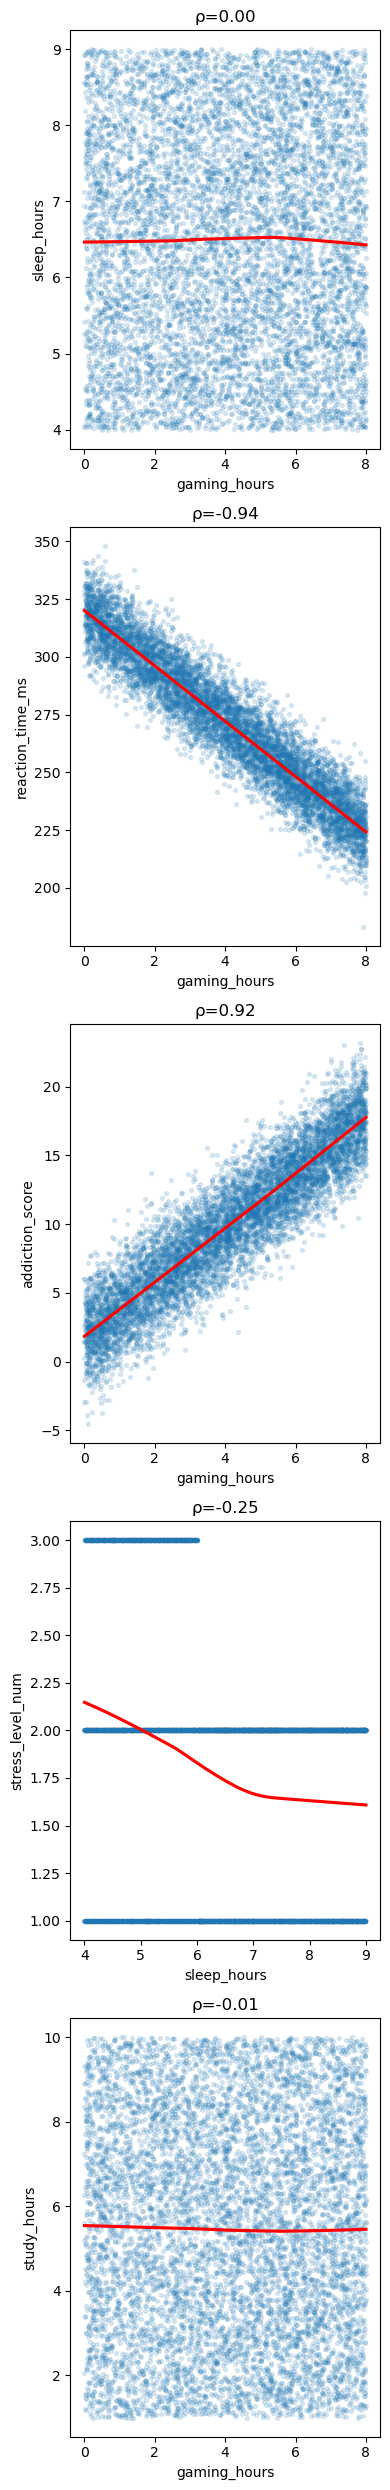

In [21]:

pairs = [('gaming_hours','sleep_hours'), ('gaming_hours','reaction_time_ms'),
         ('gaming_hours','addiction_score'), ('sleep_hours','stress_level_num'),
         ('gaming_hours','study_hours')]
fig, axes = plt.subplots(len(pairs), 1, figsize=(4,5*len(pairs)))
for ax, (x, y) in zip(axes, pairs):
    sns.regplot(data=data, x=x, y=y, lowess=True, ax=ax,
                scatter_kws={'alpha':0.15, 's':8}, line_kws={'color':'red'})
    ax.set_title(f'ρ={data[x].corr(data[y], method="spearman"):.2f}')
plt.tight_layout(); plt.show()

**Conclusion:**
- `gaming_hours` is **almost perfectly related** to `reaction_time_ms` (ρ = -0.94) and `addiction_score` (ρ = 0.92). More gaming → faster reaction time and higher addiction score.
- This explains the strange positive link between reaction time and grades: heavy gamers react **faster** *and* get **lower** grades. Reaction time itself does not cause better grades – it is a **proxy (confounding) of gaming hours**.
- `gaming_hours` is **not related** to `sleep_hours` (ρ = 0.00) or `study_hours` (ρ = -0.01). In this dataset, gaming does **not** reduce study or sleep time; its negative link with grades is a *separate* effect.
- `sleep_hours` vs `stress_level`: **High stress only appears when sleep < 6 hours**.

> **Góp ý (review):**
> `figsize=(4, 25)` làm hình rất dài và hẹp, khó đọc. Nên vẽ lưới 2×3 hoặc 1×5. Ngoài ra bạn chọn cặp biến để khám phá theo giả thuyết – đây là **điểm rất tốt**, đúng tư duy EDA.

In [22]:
features = numerical_features.tolist() + [target_variable]

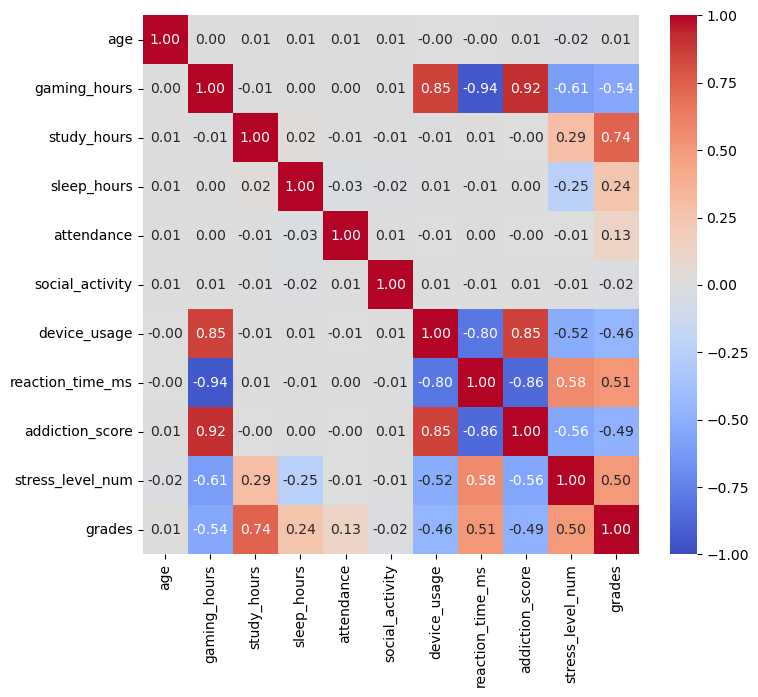

In [23]:
corr = data[features].corr(method = 'spearman')

plt.figure(figsize = (8,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.show()

**Conclusion:**
- The heatmap shows one clear **"gaming cluster"**: `gaming_hours`, `device_usage`, `reaction_time_ms` and `addiction_score` are strongly correlated with each other (|ρ| = 0.80–0.94). They mostly carry the **same information**.
- All other features (`age`, `study_hours`, `sleep_hours`, `attendance`, `social_activity`) are almost uncorrelated with each other (≈ 0) – another sign of synthetic data.
- `stress_level_num` is correlated with gaming (-0.61), study (0.29) and sleep (-0.25).

> **Góp ý (review):**
> **Bug:** list `features` có chứa `grades` (target) nên VIF bị tính cả target – VIF chỉ nên tính giữa các **feature** với nhau. Cell VIF cũ cũng chưa được chạy (không có output).

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(data[numerical_features])   # features only, no target
vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).query("feature != 'const'").sort_values('VIF', ascending=False).round(2)
vif

,feature,VIF
2,gaming_hours,15.16
8,reaction_time_ms,8.51
9,addiction_score,6.55
7,device_usage,4.05
10,stress_level_num,1.94
3,study_hours,1.20
4,sleep_hours,1.16
5,attendance,1.00
6,social_activity,1.00
1,age,1.00


**Conclusion:** `gaming_hours` has **VIF ≈ 15 (> 10 = serious multicollinearity)**, followed by `reaction_time_ms` (≈ 8.5), `addiction_score` (≈ 6.6) and `device_usage` (≈ 4.1). All other features have VIF ≈ 1.
For a linear model, keep **only `gaming_hours`** from the gaming cluster (or use Ridge/Lasso, or combine them with PCA). Tree-based models are less affected.

## 2.4. Why is high stress linked to high grades?

In [25]:
data.groupby('stress_level')[['study_hours', 'sleep_hours', 'gaming_hours']].agg(['min', 'max', 'mean']).round(2)

study_hours             sleep_hours             gaming_hours  \
                     min   max  mean         min   max  mean          min   
stress_level                                                                
High                7.01  10.0  8.45         4.0  5.99  5.02         0.00   
Low                 1.00  10.0  4.99         4.0  9.00  6.71         5.01   
Medium              1.00  10.0  5.05         4.0  9.00  6.70         0.00   

                          
               max  mean  
stress_level              
High          7.99  4.06  
Low           8.00  6.49  
Medium        5.00  2.54

In [26]:
import numpy as np

# Hypothesis from the table above:
#   High   = sleep < 6h AND study > 7h
#   Low    = gaming > 5h (and not High)
#   Medium = everyone else
rule = np.where((data['sleep_hours'] < 6) & (data['study_hours'] > 7), 'High',
       np.where(data['gaming_hours'] > 5, 'Low', 'Medium'))
print('Rule matches stress_level for', (rule == data['stress_level']).mean() * 100, '% of students')

Rule matches stress_level for 100.0 % of students


**Conclusion:** `stress_level` is **not an independent measurement**. It is a **deterministic rule** based on other columns (100% match):
- **High** = sleeps < 6 hours **and** studies > 7 hours
- **Low** = games > 5 hours (and not High)
- **Medium** = everyone else

So "High stress → high grades" is **not** evidence that stress improves grades. High-stress students are the ones who **study a lot**, and study hours drive grades. Likewise, "Low stress" students are **heavy gamers**, which explains their low grades. This is a classic example of **confounding**: correlation ≠ causation.
For modelling, `stress_level` adds almost no new information and may cause **data leakage** if the rule is not known in a real setting.

## 2.5. Going further: which features still matter together?

In [27]:
import statsmodels.formula.api as smf

formula_full = ('grades ~ study_hours + gaming_hours + sleep_hours + attendance + social_activity'
                ' + device_usage + reaction_time_ms + addiction_score + age + C(gender) + C(gaming_genre)')
full = smf.ols(formula_full, data=data).fit()
small = smf.ols('grades ~ study_hours + gaming_hours + sleep_hours + attendance', data=data).fit()

print(f'R² full model (all features): {full.rsquared:.3f}')
print(f'R² small model (4 features) : {small.rsquared:.3f}')
pd.DataFrame({'coef': full.params, 'p_value': full.pvalues}).round(4)

R² full model (all features): 0.911
R² small model (4 features) : 0.911


,coef,p_value
Intercept,7.7647,0.0023
C(gender)[T.Male],-0.0409,0.7893
C(gender)[T.Other],-0.3255,0.4240
C(gaming_genre)[T.FPS],0.0593,0.7437
C(gaming_genre)[T.RPG],-0.0072,0.9703
study_hours,6.3021,0.0000
gaming_hours,-5.3894,0.0000
sleep_hours,3.7716,0.0000
attendance,0.2794,0.0000
social_activity,-0.0446,0.3919


**Conclusion:**
- When all features are in the model together, only **4 are significant (p < 0.05)**: `study_hours` (+6.3 points per hour), `gaming_hours` (-5.4 per hour), `sleep_hours` (+3.8 per hour) and `attendance` (+0.28 per 1%).
- `device_usage`, `reaction_time_ms` and `addiction_score` become **non-significant** once `gaming_hours` is controlled – they are just proxies of gaming.
- These **4 features explain about 91% of the variance** in grades (R² ≈ 0.91), almost the same as the full model. A simple model is enough.
- Note: `attendance` has a small correlation (0.13) but is still significant, because the other features remove a lot of "noise" around it.

# 3. Summary

**Data quality**
- 8,000 students, 14 columns, no missing values, no duplicates, no statistical outliers.
- Invalid values: 134 grades > 100, 107 negative addiction scores; grades are capped at 100 (ceiling effect). Recommended: clip to valid ranges before modelling.
- The data is very likely **synthetic** (uniform distributions, near-zero correlations between most features, `stress_level` generated by a rule). Findings should **not** be generalised to real students.

**Key findings**
1. **Study hours** is the strongest positive driver of grades (r = 0.73).
2. **Gaming hours** is the main negative driver (r = -0.55). Gaming genre does not matter – only the amount of time.
3. `device_usage`, `reaction_time_ms` and `addiction_score` are **proxies of gaming hours** (|ρ| ≥ 0.8, high VIF) and add no new information.
4. **Sleep** and **attendance** have small but real positive effects.
5. Age, gender, social activity and gaming genre show **no relationship** with grades.
6. The positive link between stress and grades is **confounded**: stress is defined by study, sleep and gaming hours.

**Next steps**
- Clean invalid values, drop redundant gaming-related features (or use regularisation), and build a baseline linear regression with the 4 key features.
- Compare with a tree-based model (Random Forest / XGBoost) to check for non-linear effects.